# BIOT EEG Fine-Tuning (6-Class)

**Fixes applied:**
- Replaced Kaggle-only boilerplate (Cell 0) with a portable `pip install` setup cell
- Removed `matplotlib.use('Agg')` so plots render inline in Jupyter
- Replaced `sys.exit()` with `raise` so the kernel is not killed on errors
- Fixed `torch.load` to pass `weights_only=True` (PyTorch 2.6+ requirement)
- Removed unsupported `token_size` kwarg from `BIOT.from_pretrained()`
- Removed orphan Cell 2 (wrong head attribute, wrong `n_outputs=2`, duplicate/conflicting code)

**Before running:** place your EEG `.npy` files in an `eeg_data/` folder next to this notebook,
named `{category}_{n}.npy` (and optionally `{category}_{n}_sfreq.npy` for the sampling frequency).


In [1]:
# Install required packages (run once)
import subprocess, sys

packages = ["braindecode", "torch", "scikit-learn", "matplotlib", "seaborn", "numpy"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.5/568.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.9 MB/s eta 0:00:00


In [2]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files[:2]:  # just 2 files per folder
        print(os.path.join(root, f))
    if files:
        break

/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/epileptic_interictal_05_sfreq.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/normal_03_sfreq.npy


In [3]:
import os, glob

base = "/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data"

# Show what's actually inside
print("=== Folder contents (first 30) ===")
all_files = glob.glob(os.path.join(base, "**", "*"), recursive=True)
for f in sorted(all_files)[:30]:
    print(f)

print(f"\nTotal files: {len(all_files)}")

=== Folder contents (first 30) ===
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_01.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_01_sfreq.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_02.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_02_sfreq.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_03.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_03_sfreq.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_04.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_04_sfreq.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_05.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_05_sfreq.npy
/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data/alcoholism_06.npy
/kaggle/input/datasets

In [4]:
"""
BIOT Fine-Tuning for 6-Class EEG Classification
=================================================
Loads pretrained BIOT weights from HuggingFace (braindecode/biot-pretrained-prest-16chs)
and fine-tunes on your 7-category EEG dataset.

Key design decisions:
  - Data resampled / channel-selected to match BIOT's 16-ch / 200 Hz pretraining spec
  - Encoder is partially frozen for first N epochs (warm-up), then fully unfrozen
  - Classification head replaced with a fresh 7-class head
  - Differential learning rates: lower LR for encoder, higher for head

Run on Kaggle:
  !pip install braindecode -q
  !python eeg_biot_finetune.py
"""

import os, glob, warnings, sys
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# ── Config ─────────────────────────────────────────────────────────────────────
BASE            = "/kaggle/input/datasets/zyadhamed/eeg-downloaded-dataset/eeg_data"
CATEGORIES      = [
    "normal", "seizure", "alcoholism",
    "motor_abnormality", "mental_stress", "epileptic_interictal",
]
N_CLASSES       = 6

# BIOT pretraining spec — we conform our data to this
BIOT_SFREQ      = 200          # Hz
BIOT_N_CHANNELS = 16           # channels
BIOT_TOKEN_SIZE = 200          # samples per token  (= 1 s at 200 Hz)
BIOT_HOP        = 100          # hop length
WINDOW_SEC      = 10.0         # seconds per training window (matches BIOT paper)

DEFAULT_SFREQ   = 256.0

# Training
FREEZE_EPOCHS   = 5            # epochs with encoder frozen (head warm-up)
TOTAL_EPOCHS    = 35
BATCH_SIZE      = 32
LR_HEAD         = 1e-3
LR_ENCODER      = 1e-5         # much smaller for pretrained weights
SEED            = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── 1. Load pretrained BIOT ────────────────────────────────────────────────────
print("\nLoading pretrained BIOT from HuggingFace …")
try:
    from braindecode.models import BIOT
    model = BIOT.from_pretrained(
        "braindecode/biot-pretrained-prest-16chs",
        n_outputs=N_CLASSES,
        n_chans=BIOT_N_CHANNELS,
        n_times=int(WINDOW_SEC * BIOT_SFREQ),
        sfreq=BIOT_SFREQ,
        hop_length=BIOT_HOP,
    )
    print("  ✓ Pretrained BIOT loaded")
    USE_BIOT = True
except Exception as e:
    print(f"  ✗ Could not load BIOT: {e}")
    print("  Falling back to BIOT architecture trained from scratch …")
    USE_BIOT = False

if not USE_BIOT:
    try:
        from braindecode.models import BIOT
        model = BIOT(
            n_outputs=N_CLASSES,
            n_chans=BIOT_N_CHANNELS,
            n_times=int(WINDOW_SEC * BIOT_SFREQ),
            sfreq=BIOT_SFREQ,
            hop_length=BIOT_HOP,
            token_size=BIOT_TOKEN_SIZE,
        )
        print("  ✓ BIOT (random init) created")
    except Exception as e:
        raise RuntimeError(f"❌ braindecode BIOT unavailable: {e}\n   Run: pip install braindecode -q")

model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Total params: {total_params:,}")

# ── 2. Identify encoder vs head parameters ─────────────────────────────────────
# braindecode BIOT names the classification head 'classification_head' or 'clf_head'
head_param_names = []
encoder_param_names = []
for name, _ in model.named_parameters():
    if any(k in name for k in ("classification_head", "clf_head", "fc", "classifier")):
        head_param_names.append(name)
    else:
        encoder_param_names.append(name)

print(f"  Encoder params: {len(encoder_param_names)}  |  Head params: {len(head_param_names)}")

# ── 3. Data loading & preprocessing ───────────────────────────────────────────

def resample_array(data: np.ndarray, orig_sfreq: float, target_sfreq: float) -> np.ndarray:
    """Simple linear-interpolation resampling along time axis."""
    if abs(orig_sfreq - target_sfreq) < 1:
        return data
    orig_len = data.shape[1]
    target_len = int(orig_len * target_sfreq / orig_sfreq)
    x_old = np.linspace(0, 1, orig_len)
    x_new = np.linspace(0, 1, target_len)
    return np.stack([np.interp(x_new, x_old, ch) for ch in data])


def select_channels(data: np.ndarray, n_target: int) -> np.ndarray:
    """Select / pad to exactly n_target channels."""
    n_ch = data.shape[0]
    if n_ch >= n_target:
        # evenly spaced selection to preserve spatial spread
        idx = np.round(np.linspace(0, n_ch - 1, n_target)).astype(int)
        return data[idx]
    else:
        # zero-pad missing channels
        pad = np.zeros((n_target - n_ch, data.shape[1]), dtype=data.dtype)
        return np.vstack([data, pad])


def load_windows(category: str, label: int):
    X, y = [], []
    files = sorted([f for f in glob.glob(os.path.join(BASE, f"{category}_[0-9]*.npy"))
                    if "_sfreq" not in f])
    if not files:
        print(f"  ⚠  No files for '{category}'")
        return X, y

    win_len  = int(WINDOW_SEC * BIOT_SFREQ)
    step_len = win_len // 2   # 50 % overlap

    for fpath in files:
        data = np.load(fpath).astype(np.float32)
        sfreq_path = fpath.replace(".npy", "_sfreq.npy")
        sfreq = float(np.load(sfreq_path)) if os.path.exists(sfreq_path) else DEFAULT_SFREQ

        data = resample_array(data, sfreq, BIOT_SFREQ)
        data = select_channels(data, BIOT_N_CHANNELS)

        # per-channel z-score
        data = (data - data.mean(1, keepdims=True)) / (data.std(1, keepdims=True) + 1e-8)

        n_samp = data.shape[1]
        if n_samp < win_len:
            data = np.pad(data, ((0, 0), (0, win_len - n_samp)))
            n_samp = win_len

        for start in range(0, n_samp - win_len + 1, step_len):
            X.append(data[:, start:start + win_len])
            y.append(label)
    return X, y


print("\nLoading & preprocessing data …")
all_X, all_y = [], []
for lbl, cat in enumerate(CATEGORIES):
    X, y = load_windows(cat, lbl)
    print(f"  {cat:28s}  {len(X):4d} windows")
    all_X.extend(X)
    all_y.extend(y)

if not all_X:
    raise FileNotFoundError("❌  No data found. Ensure eeg_data/ is present.")

all_X = np.stack(all_X).astype(np.float32)   # (N, 16, T)
all_y = np.array(all_y, dtype=np.int64)
print(f"\nDataset: {all_X.shape}  |  Class dist: {np.bincount(all_y)}")

# ── 4. Split ───────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    all_X, all_y, test_size=0.2, stratify=all_y, random_state=SEED)
X_train, X_val, y_train, y_val   = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=SEED)
print(f"Split → train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=(device.type == "cuda"))

train_loader = make_loader(X_train, y_train)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

# ── 5. Optimiser with differential LR ─────────────────────────────────────────
head_params    = [p for n, p in model.named_parameters() if n in head_param_names]
encoder_params = [p for n, p in model.named_parameters() if n in encoder_param_names]

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": LR_ENCODER, "weight_decay": 1e-4},
    {"params": head_params,    "lr": LR_HEAD,    "weight_decay": 1e-4},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# ── 6. Training loop ───────────────────────────────────────────────────────────

def set_encoder_grad(requires_grad: bool):
    for n, p in model.named_parameters():
        if n in encoder_param_names:
            p.requires_grad = requires_grad


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0., 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(xb)
            # braindecode models sometimes return (logits, features) tuple
            if isinstance(out, tuple):
                out = out[0]
            loss = criterion(out, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(xb)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += len(xb)
    return total_loss / total, correct / total


print(f"\n{'='*65}")
print(f"Fine-tuning BIOT  |  freeze encoder for first {FREEZE_EPOCHS} epochs")
print(f"{'='*65}")
print(f"{'Epoch':>6}  {'Phase':>8}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Va Loss':>8}  {'Va Acc':>7}")
print("-" * 55)

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, TOTAL_EPOCHS + 1):
    # Phase: frozen encoder for warm-up, then full fine-tune
    if epoch <= FREEZE_EPOCHS:
        set_encoder_grad(False)
        phase = "frozen"
    else:
        set_encoder_grad(True)
        phase = "full FT"

    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    flag = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), "eeg_biot_best.pt")
        flag = " ← best"

    if epoch % 5 == 0 or epoch == 1 or epoch == FREEZE_EPOCHS + 1:
        print(f"{epoch:6d}  {phase:>8}  {tr_loss:8.4f}  {tr_acc*100:6.1f}%  "
              f"{va_loss:8.4f}  {va_acc*100:6.1f}%{flag}")

print(f"\nBest val accuracy: {best_val_acc*100:.1f}%  →  eeg_biot_best.pt")



Device: cuda

Loading pretrained BIOT from HuggingFace …


config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/13.8M [00:00<?, ?B/s]

  ✓ Pretrained BIOT loaded
  Total params: 3,187,718
  Encoder params: 55  |  Head params: 2

Loading & preprocessing data …
  normal                         110 windows
  seizure                        100 windows
  alcoholism                     231 windows
  motor_abnormality              233 windows
  mental_stress                  110 windows
  epileptic_interictal           844 windows

Dataset: (1628, 16, 2000)  |  Class dist: [110 100 231 233 110 844]
Split → train=1106  val=196  test=326

Fine-tuning BIOT  |  freeze encoder for first 5 epochs
 Epoch     Phase   Tr Loss   Tr Acc   Va Loss   Va Acc
-------------------------------------------------------
     1    frozen    1.4157    54.2%    1.1584    60.7% ← best
     5    frozen    0.7289    79.6%    0.7894    79.6% ← best
     6   full FT    0.6743    82.0%    0.6753    81.6% ← best
    10   full FT    0.5858    81.8%    0.6389    82.7% ← best
    15   full FT    0.5539    85.0%    0.6276    83.7%
    20   full FT    0.5351  


TEST SET RESULTS
                      precision    recall  f1-score   support

              normal      0.333     0.136     0.194        22
             seizure      1.000     0.850     0.919        20
          alcoholism      0.564     0.674     0.614        46
   motor_abnormality      0.549     0.596     0.571        47
       mental_stress      0.957     1.000     0.978        22
epileptic_interictal      0.988     1.000     0.994       169

            accuracy                          0.828       326
           macro avg      0.732     0.709     0.712       326
        weighted avg      0.819     0.828     0.820       326


Plot saved → eeg_biot_results.png
Done! 🎉


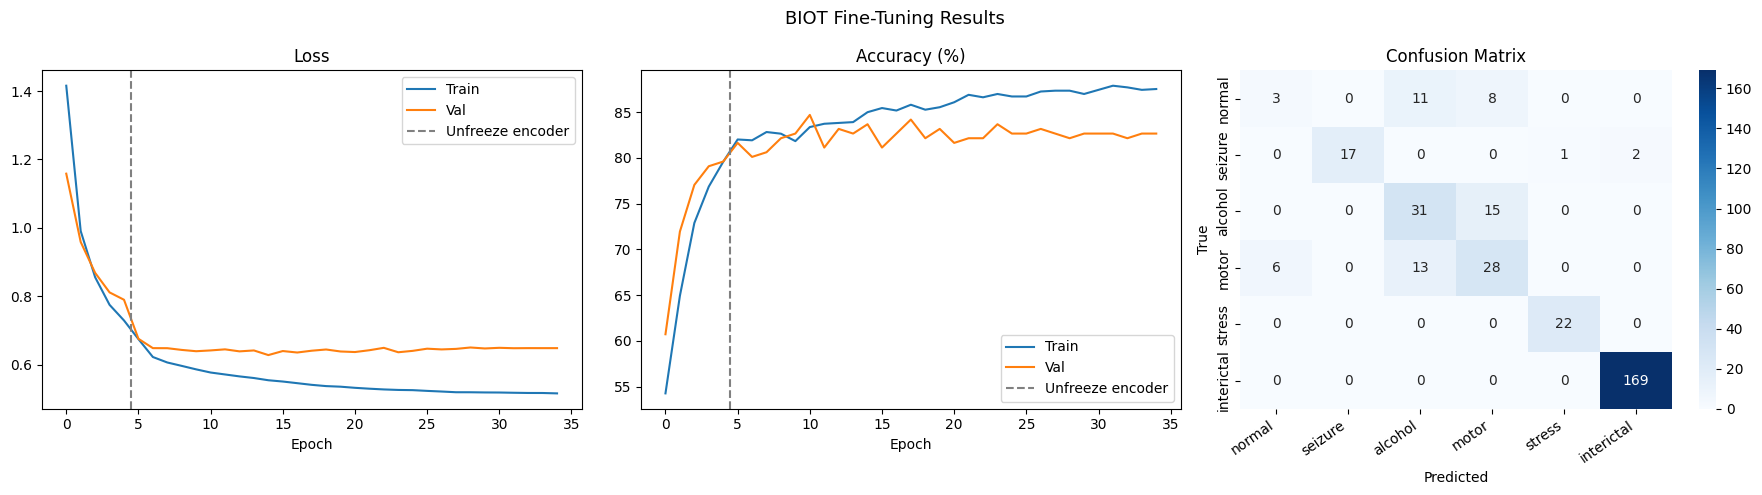

In [5]:
# ── 7. Test evaluation ─────────────────────────────────────────────────────────
model.load_state_dict(torch.load("eeg_biot_best.pt", map_location=device, weights_only=True))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(device))
        if isinstance(out, tuple):
            out = out[0]
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

print("\n" + "="*65)
print("TEST SET RESULTS")
print("="*65)
print(classification_report(all_true, all_preds,
                             labels=list(range(N_CLASSES)),
                             target_names=CATEGORIES,
                             digits=3, zero_division=0))

# ── 8. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BIOT Fine-Tuning Results", fontsize=13)

ax = axes[0]
ax.plot(history["train_loss"], label="Train")
ax.plot(history["val_loss"],   label="Val")
ax.axvline(FREEZE_EPOCHS - 0.5, color="gray", ls="--", label="Unfreeze encoder")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.legend()

ax = axes[1]
ax.plot([v*100 for v in history["train_acc"]], label="Train")
ax.plot([v*100 for v in history["val_acc"]],   label="Val")
ax.axvline(FREEZE_EPOCHS - 0.5, color="gray", ls="--", label="Unfreeze encoder")
ax.set_title("Accuracy (%)"); ax.set_xlabel("Epoch"); ax.legend()

cm = confusion_matrix(all_true, all_preds)
short = ["normal", "seizure", "alcohol", "motor", "stress", "interictal"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=short, yticklabels=short, ax=axes[2])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
plt.setp(axes[2].get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig("eeg_biot_results.png", dpi=150)
print("\nPlot saved → eeg_biot_results.png")
print("Done! 🎉")